In [1]:
import sys

sys.path.append("..")
sys.path.append("../..")

In [2]:
import os
import copy
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from os.path import join as pjoin

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch import nn

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from utils.misc import load_config, load_model_from_checkpoint, precision_recall_f1_score
from datasets.data_preparation import prepare_data

/home/nasim/anaconda3/envs/ML/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
exp_path = '../../results/dl.vit/2023-09-20 01Hr 00Min 08Sec IST+0530'

config = load_config('.', exp_path, 'hyperparameters.yaml')

In [4]:
trainer_config = config['trainer']
data_config = config['data']

model_name = config['model']['__name__']

checkpoint_name = trainer_config['checkpoint_name']
device = trainer_config['device']
batch_size = trainer_config['batch_size']

patch_size = data_config['patch']['patch_size']
lithology_classes = data_config['lithology_classes']

config['root'] = '../..'

In [5]:
config['model']['return_attention_map'] = False

In [6]:
if model_name.startswith('dl'):
    if model_name.endswith('vit'):
        if config['model']['autoregressive']:
            print('Using ViT Auto Regressor')
            from model.vit_autoregressor import build_model
            from engine.autoregressor import validation_engine as blind_engine
        else:
            print('Using ViT')
            from model.vit import build_model
            from engine.vit import validation_engine as blind_engine
    elif model_name.endswith('ann'):
        print('Using ANN')
        from model.ann import build_model
        from engine.vit import validation_engine as blind_engine

model = build_model(config)

Using ViT Auto Regressor
Building the model...


In [7]:
from peft import LoraConfig, get_peft_model

if config['model']['use_lora']:
     print('Using LORA')
     lora_config = LoraConfig(**config['model']['lora'])
     model = get_peft_model(model, lora_config)
     model, _ = load_model_from_checkpoint(model, checkpoint_name, exp_path, device)
else:
     print('Not using LORA')
     model, _ = load_model_from_checkpoint(model, checkpoint_name, exp_path, device)
model = model.to(device)

Not using LORA
Loading model from checkpoint...


In [8]:
# import random
# import pandas as pd
# from os.path import join as pjoin

# root = '../../data/processed'

# xPath = pjoin(root, 'blind_X.h5')
# yPath = pjoin(root, 'blind_Y.h5')

# X = pd.read_hdf(xPath)
# Y = pd.read_hdf(yPath)

# list_wells = list(X.UWI.unique())
# for i, well in enumerate(list_wells):
#     check_X = X[X.UWI == well]
#     check_Y = Y[X.UWI == well]
#     check_X.to_hdf(f'../../data/processed/{i}_X.h5', key='X', mode='w')
#     check_Y.to_hdf(f'../../data/processed/{i}_Y.h5', key='Y', mode='w')

In [9]:
config['data']['x_file_name'] = 'blind_X.h5'
config['data']['y_file_name'] = 'blind_Y.h5'

config['trainer']['experiment_path'] = pjoin('../..', config['trainer']['experiment_path'])

# config['data']['patch']['stride'] = 15#config['data']['patch']['patch_size']
config['model']['use_lora'] = False

x_blind, _, y_blind, _, num_classes = prepare_data(config, test = True, scaler_save=False)

blind_dataset = TensorDataset(x_blind, y_blind)
blindloader = DataLoader(blind_dataset, batch_size=batch_size, shuffle=False)

Preparing the data...
Loading scaler for GR...
Loading scaler for NPHI...
Loading scaler for DPHI...
Loading scaler for ILD...
Loading scaler for VSH...


Creating Patches: 100%|██████████| 10/10 [00:00<00:00, 499.19it/s]

Number of classes: 6 and shape of x_train: torch.Size([17, 150, 5])


In [10]:
np.unique(y_blind[:, :, 0], return_counts=True)

(array([0., 1., 2., 3., 4., 5.]), array([600, 572,  51, 803, 514,  10]))

In [11]:
# config['data']['x_file_name'] = 'X.h5'
# config['data']['y_file_name'] = 'Y.h5'

# config['trainer']['experiment_path'] = pjoin('../..', config['trainer']['experiment_path'])

# # config['data']['patch']['stride'] = 15#config['data']['patch']['patch_size']
# config['model']['use_lora'] = False

# _, x_val, _, y_val, _ = prepare_data(config)

# valdataset = TensorDataset(x_val, y_val)
# valloader = DataLoader(valdataset, batch_size=batch_size, shuffle=False)

In [12]:
# invert key as value and value as key
lithology_names = {v: k for k, v in lithology_classes.items()}

In [13]:
classification_criterion = nn.CrossEntropyLoss()
regression_criterion = nn.MSELoss()
# regression_criterion = nn.L1Loss()

In [14]:
if config['model']['autoregressive']:
    val_loss, lith_val_loss, phi_val_loss, sw_val_loss, val_accuracy, cm_val = blind_engine(1,
                                                        model,
                                                        blindloader,
                                                        regression_criterion,
                                                        classification_criterion,
                                                        1,
                                                        config['model']['loss_weights'],
                                                        device,
                                                        150,
                                                        6)
else:
    val_loss, lith_val_loss, phi_val_loss, sw_val_loss, val_accuracy, cm_val = blind_engine(1,
                                                        model,
                                                        blindloader,
                                                        regression_criterion,
                                                        classification_criterion,
                                                        1,
                                                        config['model']['loss_weights'],
                                                        device,)

Val - Epoch 2/1: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]


In [15]:
phi_val_loss, sw_val_loss, val_accuracy

(0.0020130048505961895, 0.02695567160844803, 88.74509684244791)

/home/nasim/phd/lithology_petrophysical_parm_est_ARViT/notebooks/ml/../../utils/misc.py:391: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(cm) / np.sum(cm, axis = 0)


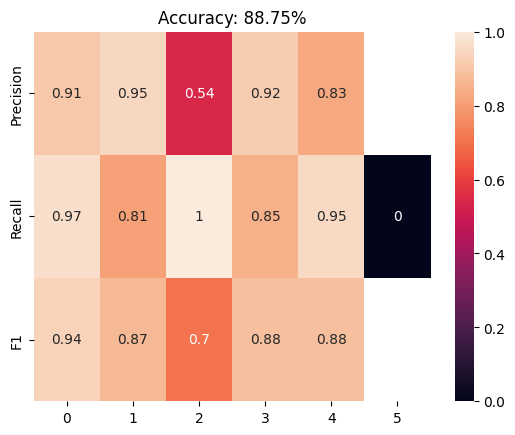

In [16]:
from utils.misc import precision_recall_f1_score
precision_recall_f1_score(cm_val, lithology_names)